In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# split data into training and test sets:

# Load data
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

In [11]:
# Initialize the Gaussian Naive Bayes model
model = GaussianNB()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

In [10]:
# Classification metrics table
report_dict = classification_report(
    y_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df = metrics_df
metrics_df.index = ["No Diabetes", "Diabetes", "Accuracy", "Macro Avg", "Weighted Avg"]


display(metrics_df.style.set_caption("Naive-Bayes Classification Metrics").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
))

,precision,recall,f1-score,support
No Diabetes,0.714748,0.725028,0.719852,8830.000000
Diabetes,0.721432,0.711071,0.716214,8843.000000
Accuracy,0.718044,0.718044,0.718044,0.718044
Macro Avg,0.718090,0.718050,0.718033,17673.000000
Weighted Avg,0.718093,0.718044,0.718031,17673.000000


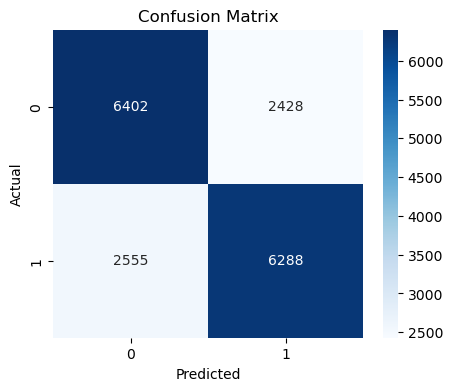

In [9]:
# Evaluate model:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


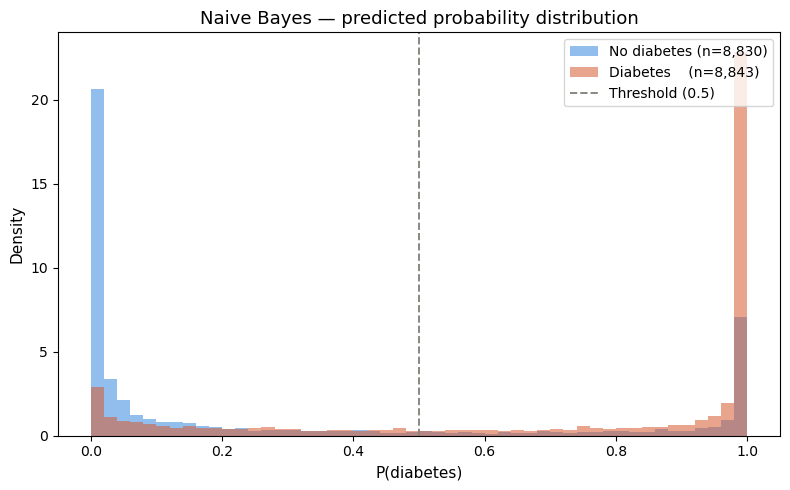

In [21]:
import matplotlib.pyplot as plt
import numpy as np

y_proba = model.predict_proba(X_test)[:, 1]

proba_no_diab = y_proba[y_test.values == 0]
proba_diab    = y_proba[y_test.values == 1]

bins = np.linspace(0, 1, 51)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(proba_no_diab, bins=bins, alpha=0.55, color='#378ADD',
        label=f'No diabetes (n={len(proba_no_diab):,})', density=True)
ax.hist(proba_diab,    bins=bins, alpha=0.55, color='#D85A30',
        label=f'Diabetes    (n={len(proba_diab):,})',    density=True)

ax.axvline(0.5, color='#888780', linewidth=1.4,
           linestyle='--', label='Threshold (0.5)')

ax.set_xlabel('P(diabetes)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Naive Bayes — predicted probability distribution', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('nb_prob_distribution.png', dpi=150)
plt.show()